In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import polars as pl

from backtester.dtypes import SpotInstrument
from backtester import io, samplers

In [3]:
plt.rcParams["figure.facecolor"] = "darkgray"
plt.rcParams["axes.facecolor"] = "lightgray"

In [4]:
t0 = datetime(2023, 1, 1, tzinfo=timezone.utc)
tt = datetime(2023, 1, 15, tzinfo=timezone.utc)
tf = datetime(2023, 2, 28, tzinfo=timezone.utc)
dt = timedelta(hours=1)

In [5]:
path_rate = samplers.get_path_rate(t0, tf, dt)
paths_mark = samplers.get_paths_mark(t0, tf, dt)
bars_spot = paths_mark.pipe(samplers.to_bars_spot, ["binc", "cbse"], ["usd", "usdt"])
bars_option = paths_mark.pipe(samplers.to_bars_option, "drbt", "btc", "usd")

path_rate.show()
paths_mark.show()
bars_spot.show()
bars_option.show()

time_start,time_end,rate
"datetime[μs, UTC]","datetime[μs, UTC]",f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,0.05
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,0.050001
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,0.049852
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,0.049951
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,0.050034


time_start,time_end,name,price
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,"""btc""",100357.911524
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,"""btc""",100776.915027
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,"""btc""",100781.99392
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,"""btc""",100792.395132
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,"""btc""",99539.922772


time_start,time_end,base,px_mark,exchange,quote,px_bid,px_ask
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,str,str,f64,f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,"""btc""",100357.911524,"""binc""","""usd""",99354.332409,101361.490639
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,"""btc""",100776.915027,"""binc""","""usd""",99769.145877,101784.684177
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,"""btc""",100781.99392,"""binc""","""usd""",99774.173981,101789.81386
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,"""btc""",100792.395132,"""binc""","""usd""",99784.47118,101800.319083
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,"""btc""",99539.922772,"""binc""","""usd""",98544.523544,100535.322


time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,iv_bid,iv_ask,iv_mark
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64
2023-01-06 08:00:00 UTC,2023-01-06 09:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-06 09:00:00 UTC,2023-01-06 10:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-06 10:00:00 UTC,2023-01-06 11:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-06 11:00:00 UTC,2023-01-06 12:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-06 12:00:00 UTC,2023-01-06 13:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",0.99,1.01,1.0


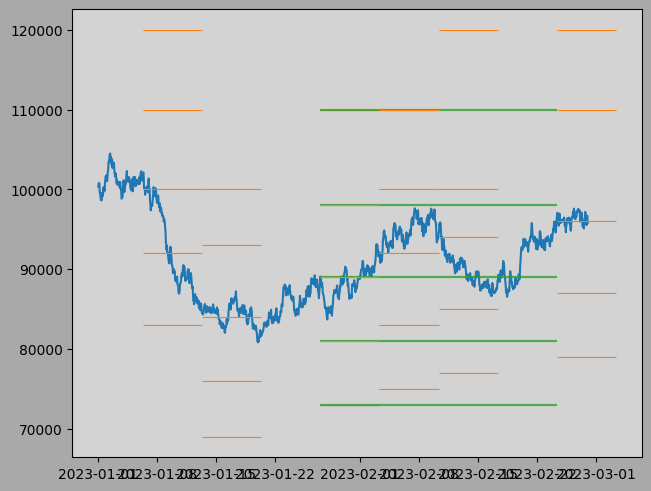

In [6]:
fig, ax = plt.subplots(layout="constrained")
ax.plot(
    paths_mark.filter(pl.col("name").eq("btc")).collect()["time_end"],
    paths_mark.filter(pl.col("name").eq("btc")).collect()["price"],
)
for k, tl, te in bars_option.select(["strike", "listing", "expiry"]).unique().collect().iter_rows():  # fmt: off
    dw = abs((te - tl) - timedelta(days=7))
    dm = abs((te - tl) - timedelta(days=30))
    dq = abs((te - tl) - timedelta(days=90))

    alphas = {dw: 1.0, dm: 0.8, dq: 0.2}
    colors = {dw: "tab:orange", dm: "tab:green", dq: "tab:red"}
    widths = {dw: 0.8, dm: 1.6, dq: 3.2}

    a = alphas[min(alphas.keys())]
    c = colors[min(colors.keys())]
    w = widths[min(widths.keys())]

    ax.hlines(k, tl, te, alpha=a, color=c, linewidth=w)

In [7]:
target_option = io.get_target_option(
    path_rate,
    bars_spot,
    bars_option,
    "drbt",
    "btc",
    "usd",
    "c",
    SpotInstrument("cbse", "btc", "usd"),
    target_time=tt,
    target_delta=0.50,
    target_tenor=timedelta(days=30),
)
target_option

ValueError: 2023-01-13 08:00:00+00:00 must have tzinfo=datetime.timezone.utc, got dt.tzinfo=zoneinfo.ZoneInfo(key='UTC')
2023-01-20 08:00:00+00:00 must have tzinfo=datetime.timezone.utc, got dt.tzinfo=zoneinfo.ZoneInfo(key='UTC')

In [ ]:
io.get_bars_option(bars_option, target_option, start_time=t0, end_time=tf).show()

time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,iv_bid,iv_ask,iv_mark
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64
2023-01-13 08:00:00 UTC,2023-01-13 09:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 09:00:00 UTC,2023-01-13 10:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 10:00:00 UTC,2023-01-13 11:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 11:00:00 UTC,2023-01-13 12:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 12:00:00 UTC,2023-01-13 13:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0


In [8]:
io.get_bars_spot(
    bars_spot, SpotInstrument("cbse", "btc", "usd"), start_time=t0, end_time=tf
).show()

time_start,time_end,base,px_mark,exchange,quote,px_bid,px_ask
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,str,str,f64,f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,"""btc""",100357.911524,"""cbse""","""usd""",99354.332409,101361.490639
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,"""btc""",100776.915027,"""cbse""","""usd""",99769.145877,101784.684177
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,"""btc""",100781.99392,"""cbse""","""usd""",99774.173981,101789.81386
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,"""btc""",100792.395132,"""cbse""","""usd""",99784.47118,101800.319083
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,"""btc""",99539.922772,"""cbse""","""usd""",98544.523544,100535.322


In [9]:
# NOTE: ~21.6s using duckdb for one month of data at dt=1h.
#       near-instant for Polars.
io._build_lf_priced(
    path_rate,
    bars_spot,
    bars_option,
    "drbt",
    "btc",
    "usd",
    "cbse",
    "btc",
    "usd",
).collect()

time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,spot,rate,iv_bid,iv_ask,iv_mark,px_bid,px_ask,px_mark,delta,gamma,vega,theta,rho
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-01-06 08:00:00 UTC,2023-01-06 09:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",102127.050082,0.050323,0.99,1.01,1.0,895.541336,957.513849,926.319444,0.137402,0.000015,3098.625657,-81931.927056,249.855125
2023-01-06 09:00:00 UTC,2023-01-06 10:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",101530.228803,0.050446,0.99,1.01,1.0,809.264519,867.598806,838.219812,0.127484,0.000015,2916.714331,-77572.653479,229.391303
2023-01-06 10:00:00 UTC,2023-01-06 11:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",100154.883103,0.05056,0.99,1.01,1.0,643.660023,694.396575,668.811135,0.107186,0.000013,2536.827613,-67852.692004,189.607199
2023-01-06 11:00:00 UTC,2023-01-06 12:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",100284.246531,0.05038,0.99,1.01,1.0,649.647206,700.620609,674.917518,0.108144,0.000013,2548.670186,-68583.047117,190.400664
2023-01-06 12:00:00 UTC,2023-01-06 13:00:00 UTC,"""drbt""","""btc""","""usd""",120000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""c""",100202.189081,0.050364,0.99,1.01,1.0,633.479231,683.613278,658.330128,0.106252,0.000014,2506.70236,-67863.558007,185.855543
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023-02-27 19:00:00 UTC,2023-02-27 20:00:00 UTC,"""drbt""","""btc""","""usd""",79000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""p""",96063.510945,0.054805,0.99,1.01,1.0,67.385763,76.539804,71.87109,-0.020114,0.000005,457.702089,-23754.458029,-19.21759
2023-02-27 20:00:00 UTC,2023-02-27 21:00:00 UTC,"""drbt""","""btc""","""usd""",79000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""p""",95523.703389,0.054761,0.99,1.01,1.0,75.63735,85.574823,80.511061,-0.022472,0.000006,496.873651,-26097.224648,-21.10207
2023-02-27 21:00:00 UTC,2023-02-27 22:00:00 UTC,"""drbt""","""btc""","""usd""",79000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""p""",96534.981637,0.05464,0.99,1.01,1.0,54.316777,62.101992,58.12547,-0.016771,0.000004,389.260739,-20698.625319,-15.698983


In [11]:
io.get_target_option(
    path_rate,
    bars_spot,
    bars_option,
    "drbt",
    "btc",
    "usd",
    "c",
    SpotInstrument("cbse", "btc", "usd"),
    target_time=tt,
    target_delta=0.50,
    target_tenor=timedelta(days=30),
)

OptionInstrument(exchange='drbt', base='btc', quote='usd', strike=84000.0, listing=datetime.datetime(2023, 1, 13, 8, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC')), expiry=datetime.datetime(2023, 1, 20, 8, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC')), kind='c')